# RAVDESS Audio Emotion Recognition


## What this notebook uses instead
- `soundfile` for audio loading
- `scipy.signal.resample_poly` for resampling
- `torchaudio.transforms` for:
  - MelSpectrogram
  - MFCC

## What this notebook includes
- environment setup
- Kaggle download
- zip extraction
- metadata generation from filenames
- preprocessing
- thesis-ready visualizations
- training and testing with:
  - CNN on mel-spectrograms
  - BiLSTM on MFCC sequences
- confusion matrix
- ROC-AUC
- training curves
- model comparison chart

In [1]:
# =========================
# 1. ENVIRONMENT SETUP
# =========================
# Run this once, then restart kernel before running the rest.

!pip uninstall -y librosa soxr datasets pyarrow sentencepiece || true
!pip install --upgrade pip setuptools wheel
!pip install --no-cache-dir "numpy==1.26.4" "scipy==1.13.1" pandas scikit-learn matplotlib tqdm kaggle
!pip install --no-cache-dir "soundfile==0.12.1"
!pip install --no-cache-dir torch torchaudio
!sudo yum install -y libsndfile

Loaded plugins: dkms-build-requires, extras_suggestions, kernel-livepatch,
              : langpacks, priorities, update-motd, versionlock
https://download.docker.com/linux/centos/2/x86_64/stable/repodata/repomd.xml: [Errno 14] HTTPS Error 404 - Not Found
Trying other mirror.
63 packages excluded due to repository priority protections
Package libsndfile-1.0.25-12.amzn2.2.1.x86_64 already installed and latest version
Nothing to do


In [2]:
# =========================
# 2. IMPORTS
# =========================
import os
import math
import json
import zipfile
import random
import warnings
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt

import soundfile as sf
from scipy.signal import resample_poly

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchaudio

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


DEVICE: cpu


In [3]:
# =========================
# 3. PROJECT PATHS
# =========================
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "ravdess_project"
RAW_DIR = DATA_DIR / "raw"
EXT_DIR = DATA_DIR / "extracted"
FIG_DIR = DATA_DIR / "figures"
CKPT_DIR = DATA_DIR / "checkpoints"
OUT_DIR = DATA_DIR / "outputs"

for d in [RAW_DIR, EXT_DIR, FIG_DIR, CKPT_DIR, OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)

BASE_DIR: /home/ec2-user/SageMaker
DATA_DIR: /home/ec2-user/SageMaker/ravdess_project


In [4]:
# =========================
# 4. KAGGLE DOWNLOAD HELPERS
# =========================
RAVDESS_KAGGLE_DATASET = "uwrfkaggler/ravdess-emotional-speech-audio"

def run_cmd(cmd):
    print("Running:", " ".join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"Command failed with code {result.returncode}")
    return result

def download_kaggle_dataset(dataset_slug, out_dir):
    out_dir.mkdir(parents=True, exist_ok=True)
    run_cmd(["kaggle", "datasets", "download", "-d", dataset_slug, "-p", str(out_dir), "--force"])

def unzip_all(zip_dir, extract_dir):
    extract_dir.mkdir(parents=True, exist_ok=True)
    for zf in zip_dir.glob("*.zip"):
        target = extract_dir / zf.stem
        target.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zf, "r") as z:
            z.extractall(target)
        print("Extracted:", zf.name, "->", target)

# Uncomment after Kaggle auth is configured
download_kaggle_dataset(RAVDESS_KAGGLE_DATASET, RAW_DIR)
unzip_all(RAW_DIR, EXT_DIR)

Running: kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio -p /home/ec2-user/SageMaker/ravdess_project/raw --force
Dataset URL: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio
License(s): CC-BY-NC-SA-4.0


Extracted: ravdess-emotional-speech-audio.zip -> /home/ec2-user/SageMaker/ravdess_project/extracted/ravdess-emotional-speech-audio


In [5]:
# =========================
# 5. DATA ROOT LOCATION
# =========================
def locate_data_root(root: Path):
    wavs = list(root.rglob("*.wav"))
    return root if wavs else None

RAVDESS_ROOT = locate_data_root(EXT_DIR)
print("RAVDESS_ROOT:", RAVDESS_ROOT)

if RAVDESS_ROOT is None:
    print("No WAV files found yet. Run the Kaggle download and unzip cells first.")

RAVDESS_ROOT: /home/ec2-user/SageMaker/ravdess_project/extracted


In [6]:
# =========================
# 6. METADATA CREATION
# =========================
RAVDESS_EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

def audio_duration(path):
    try:
        info = sf.info(str(path))
        return info.frames / info.samplerate
    except Exception:
        return np.nan

def load_ravdess_metadata(root: Path) -> pd.DataFrame:
    rows = []
    wav_files = sorted(root.rglob("*.wav"))
    for fp in wav_files:
        parts = fp.stem.split("-")
        if len(parts) >= 7:
            emotion_code = parts[2]
            actor_id = parts[-1]
            label = RAVDESS_EMOTION_MAP.get(emotion_code)
            if label:
                rows.append({
                    "audio_path": str(fp),
                    "file_name": fp.name,
                    "label": label,
                    "actor_id": actor_id,
                    "duration_sec": audio_duration(fp),
                })
    return pd.DataFrame(rows)

if RAVDESS_ROOT is not None:
    df = load_ravdess_metadata(RAVDESS_ROOT)
else:
    df = pd.DataFrame(columns=["audio_path", "file_name", "label", "actor_id", "duration_sec"])

print("Shape:", df.shape)
df.head()

Shape: (2880, 5)


,audio_path,file_name,label,actor_id,duration_sec
0,/home/ec2-user/SageMaker/ravdess_project/extra...,03-01-01-01-01-01-01.wav,neutral,01,3.303292
1,/home/ec2-user/SageMaker/ravdess_project/extra...,03-01-01-01-01-02-01.wav,neutral,01,3.336667
2,/home/ec2-user/SageMaker/ravdess_project/extra...,03-01-01-01-02-01-01.wav,neutral,01,3.269917
3,/home/ec2-user/SageMaker/ravdess_project/extra...,03-01-01-01-02-02-01.wav,neutral,01,3.169833
4,/home/ec2-user/SageMaker/ravdess_project/extra...,03-01-02-01-01-01-01.wav,calm,01,3.536854


## Thesis Visualizations: Dataset Understanding

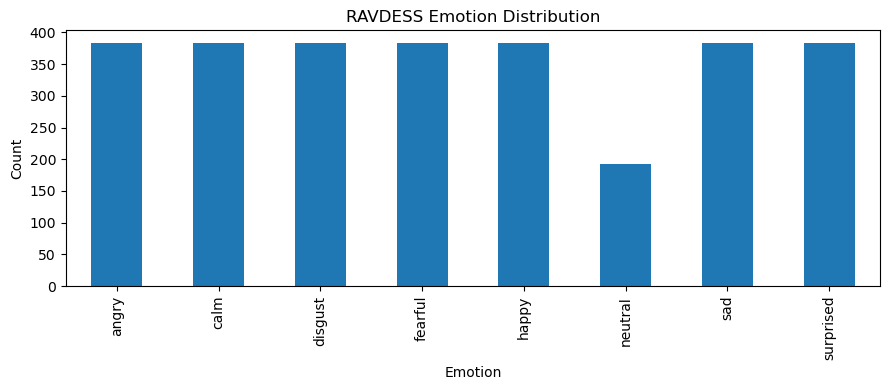

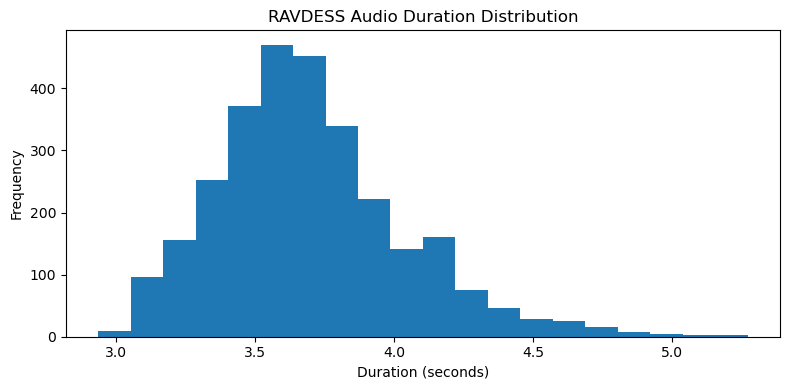

In [7]:
# =========================
# 7. EDA VISUALIZATIONS
# =========================
if len(df):
    plt.figure(figsize=(9, 4))
    df["label"].value_counts().sort_index().plot(kind="bar")
    plt.title("RAVDESS Emotion Distribution")
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ravdess_emotion_distribution.png", dpi=220)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(df["duration_sec"].dropna(), bins=20)
    plt.title("RAVDESS Audio Duration Distribution")
    plt.xlabel("Duration (seconds)")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ravdess_duration_distribution.png", dpi=220)
    plt.show()
else:
    print("Dataframe is empty.")

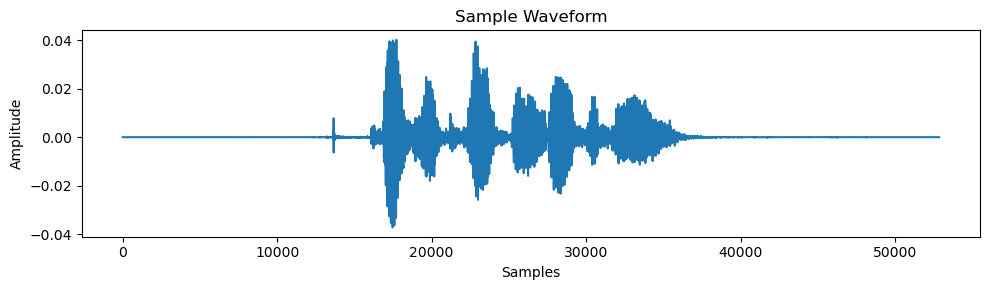

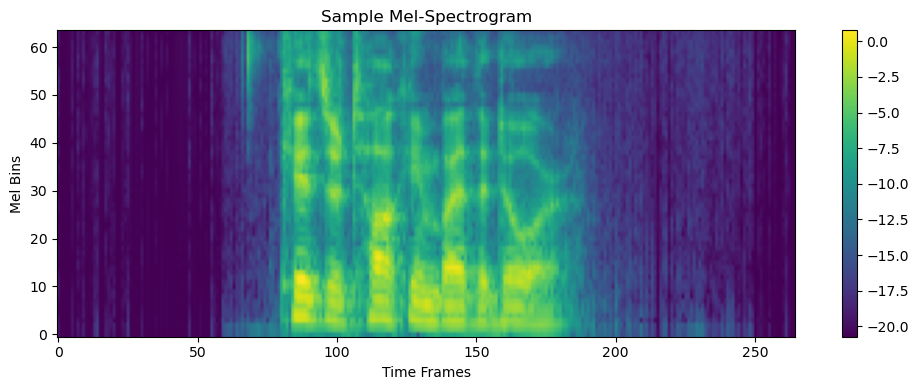

In [8]:
# =========================
# 8. SAMPLE WAVEFORM AND MEL-SPECTROGRAM
# =========================
MEL_EXTRACTOR = torchaudio.transforms.MelSpectrogram(
    sample_rate=16000,
    n_mels=64
)

def safe_read_audio(path):
    y, sr = sf.read(str(path))
    if len(y.shape) > 1:
        y = np.mean(y, axis=1)
    return y.astype(np.float32), sr

def safe_resample(y, orig_sr, target_sr=16000):
    if orig_sr == target_sr:
        return y.astype(np.float32)
    g = math.gcd(orig_sr, target_sr)
    up = target_sr // g
    down = orig_sr // g
    return resample_poly(y, up, down).astype(np.float32)

if len(df):
    sample_path = Path(df.iloc[0]["audio_path"])
    y, sr = safe_read_audio(sample_path)
    y16 = safe_resample(y, sr, 16000)

    mel = MEL_EXTRACTOR(torch.tensor(y16)).numpy()
    mel = np.log(mel + 1e-9)

    plt.figure(figsize=(10, 3))
    plt.plot(y16)
    plt.title("Sample Waveform")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ravdess_sample_waveform.png", dpi=220)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.imshow(mel, aspect="auto", origin="lower")
    plt.title("Sample Mel-Spectrogram")
    plt.xlabel("Time Frames")
    plt.ylabel("Mel Bins")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ravdess_sample_melspectrogram.png", dpi=220)
    plt.show()
else:
    print("Dataframe is empty.")

## Added Thesis-Aligned Visualisations

These extra plots align the notebook more closely with the thesis/proposal analysis sections:
- univariate analysis: class balance, duration spread, missing values
- split visualisation: train / validation / test composition
- feature analysis: RMS energy, zero-crossing rate, spectral centroid
- correlation heatmap for lightweight acoustic features


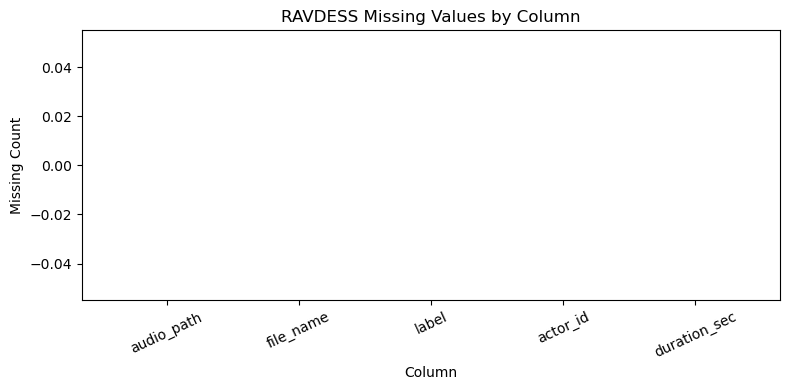

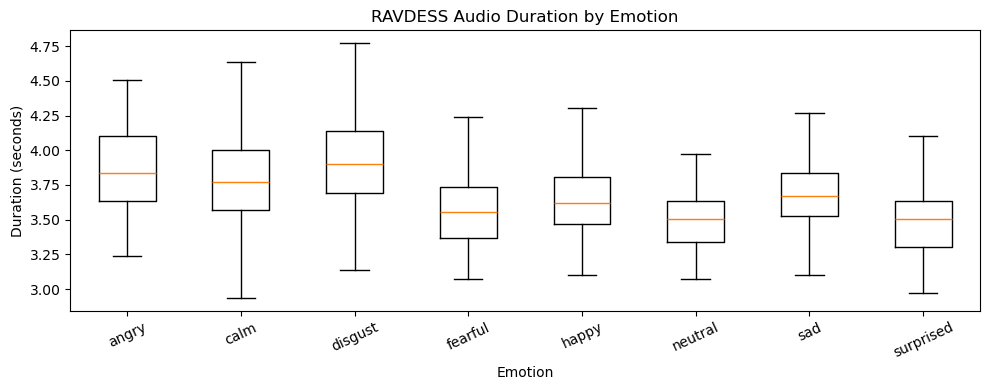

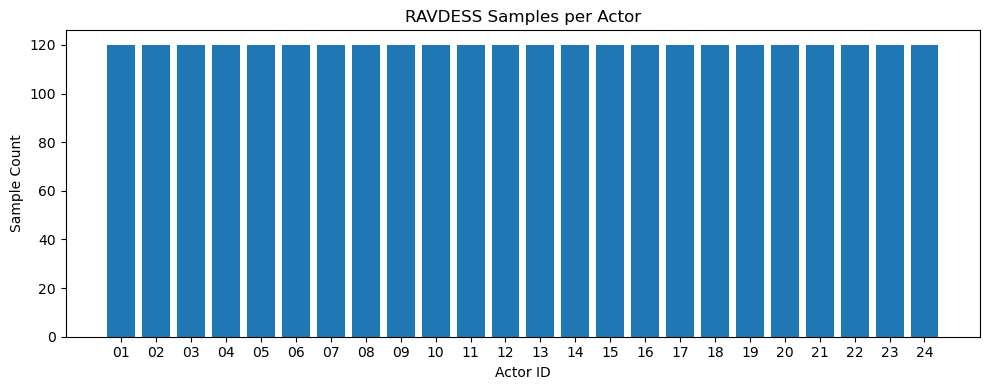

In [9]:

# =========================
# 7B. THESIS-ALIGNED UNIVARIATE VISUALS
# =========================
if len(df):
    # Missing values summary
    missing_counts = df.isna().sum().sort_values(ascending=False)
    plt.figure(figsize=(8, 4))
    plt.bar(missing_counts.index.astype(str), missing_counts.values)
    plt.title("RAVDESS Missing Values by Column")
    plt.xlabel("Column")
    plt.ylabel("Missing Count")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ravdess_missing_values.png", dpi=220)
    plt.show()

    # Duration by emotion
    duration_by_label = [df.loc[df["label"] == lab, "duration_sec"].dropna().values for lab in sorted(df["label"].unique())]
    plt.figure(figsize=(10, 4))
    plt.boxplot(duration_by_label, labels=sorted(df["label"].unique()), showfliers=False)
    plt.title("RAVDESS Audio Duration by Emotion")
    plt.xlabel("Emotion")
    plt.ylabel("Duration (seconds)")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ravdess_duration_by_emotion_boxplot.png", dpi=220)
    plt.show()

    # Actor distribution
    actor_counts = df["actor_id"].astype(str).value_counts().sort_index()
    plt.figure(figsize=(10, 4))
    plt.bar(actor_counts.index, actor_counts.values)
    plt.title("RAVDESS Samples per Actor")
    plt.xlabel("Actor ID")
    plt.ylabel("Sample Count")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ravdess_actor_distribution.png", dpi=220)
    plt.show()
else:
    print("Dataframe is empty.")


In [10]:
# =========================
# 9. LABEL ENCODING AND SPLITS
# =========================
if len(df):
    label_encoder = LabelEncoder()
    df["label_id"] = label_encoder.fit_transform(df["label"])

    train_df, test_df = train_test_split(
        df,
        test_size=0.15,
        random_state=SEED,
        stratify=df["label"],
    )

    train_df, val_df = train_test_split(
        train_df,
        test_size=0.1765,
        random_state=SEED,
        stratify=train_df["label"],
    )

    print("Train:", len(train_df))
    print("Val  :", len(val_df))
    print("Test :", len(test_df))
    print("Classes:", list(label_encoder.classes_))
else:
    label_encoder = LabelEncoder()
    train_df = val_df = test_df = pd.DataFrame()

Train: 2015
Val  : 433
Test : 432
Classes: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


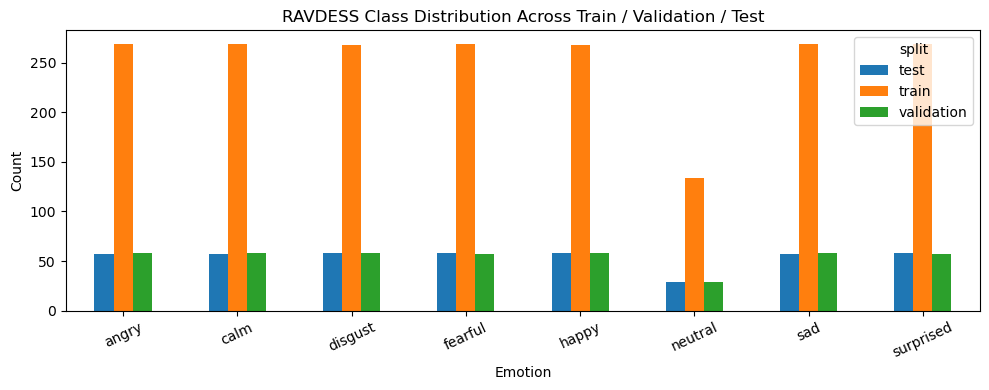

In [11]:

# =========================
# 10B. SPLIT DISTRIBUTION VISUAL
# =========================
if len(df):
    split_frames = []
    for split_name, split_df in [("train", train_df), ("validation", val_df), ("test", test_df)]:
        temp = split_df["label"].value_counts().rename_axis("label").reset_index(name="count")
        temp["split"] = split_name
        split_frames.append(temp)
    split_plot_df = pd.concat(split_frames, ignore_index=True)
    split_pivot = split_plot_df.pivot(index="label", columns="split", values="count").fillna(0)

    split_pivot.plot(kind="bar", figsize=(10, 4))
    plt.title("RAVDESS Class Distribution Across Train / Validation / Test")
    plt.xlabel("Emotion")
    plt.ylabel("Count")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ravdess_split_distribution.png", dpi=220)
    plt.show()
else:
    print("Split data unavailable.")


RAVDESS lightweight audio features: 100%|██████████| 400/400 [00:06<00:00, 60.84it/s]


,label,duration_sec,rms_energy,zcr,spectral_centroid
0,neutral,3.303292,0.099686,0.209339,1556.468272
1,neutral,3.336667,0.090131,0.229817,1505.926306
2,neutral,3.269917,0.086460,0.236381,1886.929863
3,neutral,3.169833,0.078287,0.273045,1879.338691
4,calm,3.536854,0.113349,0.211101,1689.561180


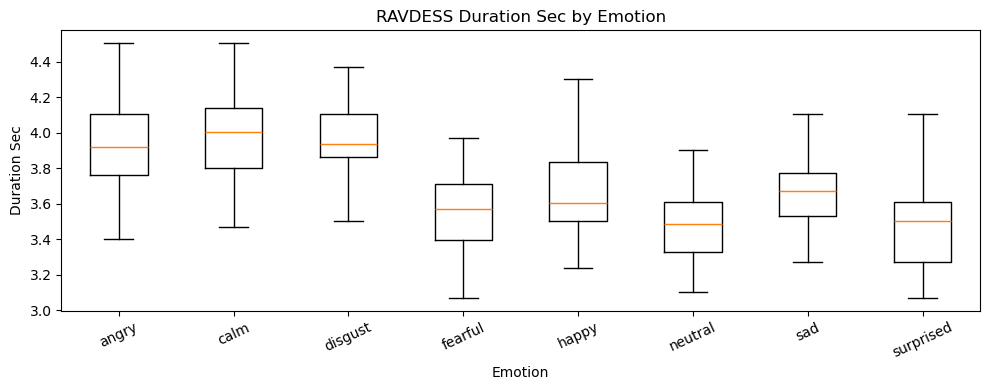

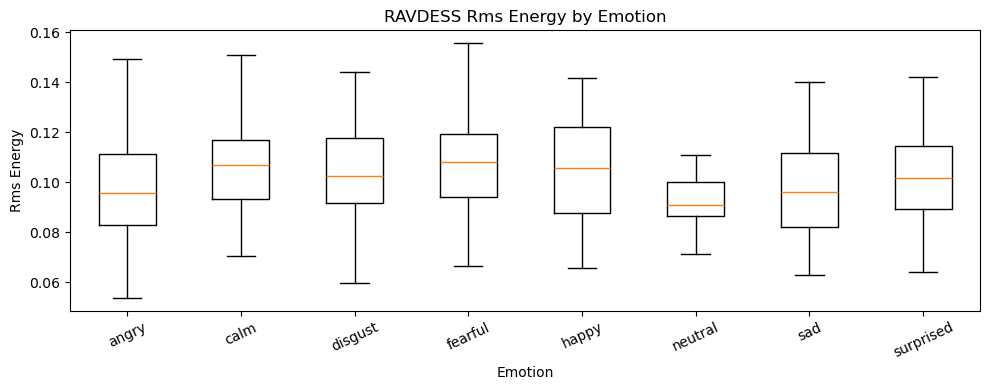

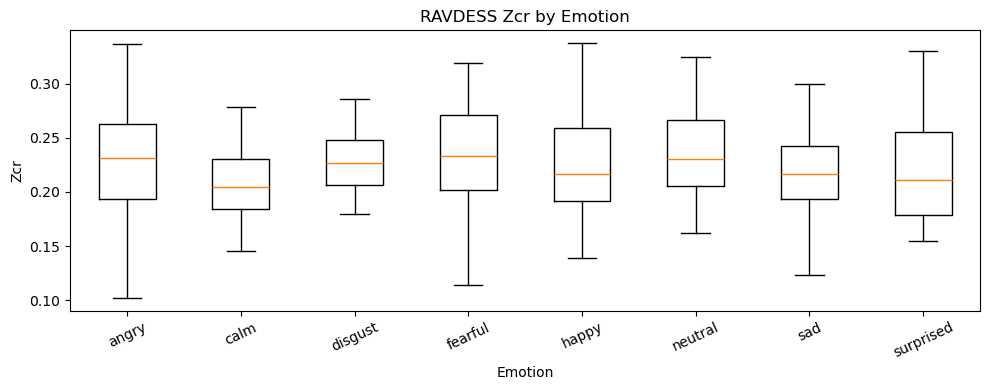

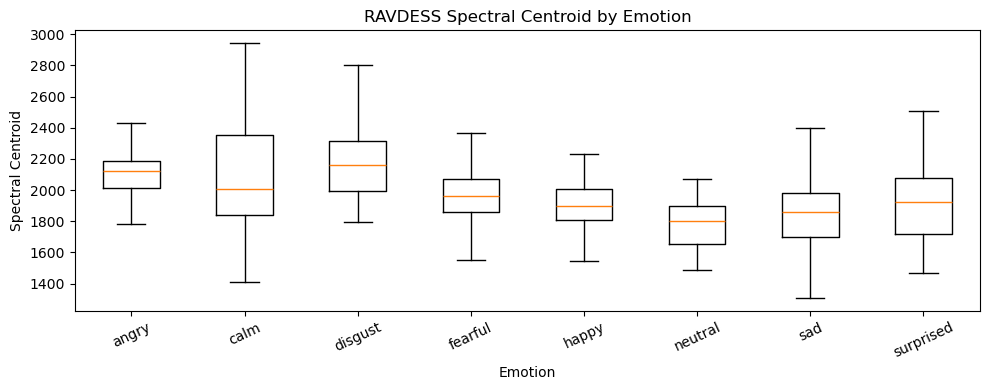

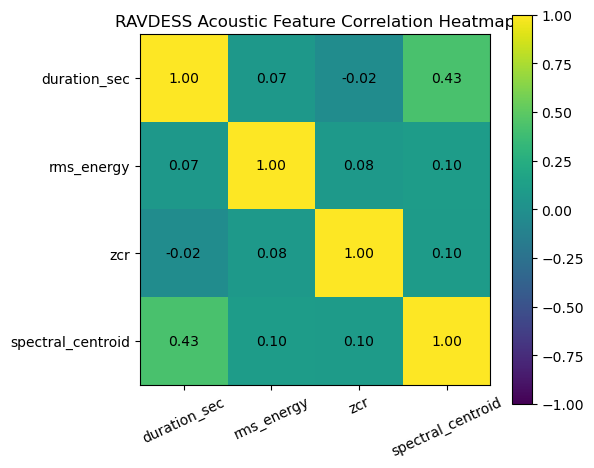

In [12]:

# =========================
# 10C. LIGHTWEIGHT ACOUSTIC FEATURE ANALYSIS
# =========================
def compute_lightweight_audio_features(frame, sample_limit=400):
    rows = []
    work = frame.head(sample_limit).copy()
    for _, row in tqdm(work.iterrows(), total=len(work), desc="RAVDESS lightweight audio features"):
        try:
            y, sr = safe_read_audio(Path(row["audio_path"]))
            y = safe_resample(y, sr, 16000)
            if np.max(np.abs(y)) > 0:
                y = y / np.max(np.abs(y))
            spec = np.abs(np.fft.rfft(y))
            freqs = np.fft.rfftfreq(len(y), d=1/16000)
            centroid = float((freqs * spec).sum() / (spec.sum() + 1e-9))
            rows.append({
                "label": row["label"],
                "duration_sec": float(row.get("duration_sec", np.nan)),
                "rms_energy": float(np.sqrt(np.mean(y**2))),
                "zcr": float(np.mean(np.abs(np.diff(np.signbit(y).astype(np.int8))))),
                "spectral_centroid": centroid,
            })
        except Exception:
            continue
    return pd.DataFrame(rows)

if len(df):
    acoustic_df = compute_lightweight_audio_features(df)
    display(acoustic_df.head())

    feature_cols = ["duration_sec", "rms_energy", "zcr", "spectral_centroid"]

    for feat in feature_cols:
        grouped = [acoustic_df.loc[acoustic_df["label"] == lab, feat].dropna().values for lab in sorted(acoustic_df["label"].unique())]
        plt.figure(figsize=(10, 4))
        plt.boxplot(grouped, labels=sorted(acoustic_df["label"].unique()), showfliers=False)
        plt.title(f"RAVDESS {feat.replace('_', ' ').title()} by Emotion")
        plt.xlabel("Emotion")
        plt.ylabel(feat.replace("_", " ").title())
        plt.xticks(rotation=25)
        plt.tight_layout()
        plt.savefig(FIG_DIR / f"ravdess_{feat}_by_emotion.png", dpi=220)
        plt.show()

    corr = acoustic_df[feature_cols].corr(numeric_only=True)
    plt.figure(figsize=(6, 5))
    plt.imshow(corr, vmin=-1, vmax=1)
    plt.xticks(range(len(feature_cols)), feature_cols, rotation=25)
    plt.yticks(range(len(feature_cols)), feature_cols)
    for i in range(len(feature_cols)):
        for j in range(len(feature_cols)):
            plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")
    plt.title("RAVDESS Acoustic Feature Correlation Heatmap")
    plt.colorbar()
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ravdess_acoustic_feature_correlation.png", dpi=220)
    plt.show()
else:
    print("No audio rows available.")


In [13]:
# =========================
# 10. AUDIO LOADER
# =========================
MAX_SEC = 4
SR = 16000
N_MELS = 64
N_MFCC = 40
BATCH_SIZE = 16
EPOCHS = 8

MEL_EXTRACTOR = torchaudio.transforms.MelSpectrogram(sample_rate=SR, n_mels=N_MELS)
MFCC_EXTRACTOR = torchaudio.transforms.MFCC(sample_rate=SR, n_mfcc=N_MFCC)

def load_fixed_audio(path, sr=SR, max_sec=MAX_SEC):
    y, orig_sr = safe_read_audio(path)
    y = safe_resample(y, orig_sr, sr)

    if np.max(np.abs(y)) > 0:
        y = y / np.max(np.abs(y))

    target_len = sr * max_sec
    if len(y) > target_len:
        y = y[:target_len]
    elif len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))

    return y.astype(np.float32)

In [14]:
# =========================
# 11. DATASET CLASS
# =========================
class RavdessDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, mode="mel"):
        self.frame = frame.reset_index(drop=True)
        self.mode = mode

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        y = load_fixed_audio(row["audio_path"])
        y_t = torch.tensor(y, dtype=torch.float32)
        label = int(row["label_id"])

        if self.mode == "mel":
            feat = MEL_EXTRACTOR(y_t)
            feat = torch.log(feat + 1e-9).unsqueeze(0) if feat.ndim == 2 else torch.log(feat + 1e-9)
        else:
            feat = MFCC_EXTRACTOR(y_t).transpose(0, 1)

        return feat, torch.tensor(label, dtype=torch.long)

In [15]:
# =========================
# 12. MODELS
# =========================
class CNNMelNet(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

class BiLSTMMFCCNet(nn.Module):
    def __init__(self, n_classes, input_dim=N_MFCC, hidden_dim=128):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes),
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.classifier(out[:, -1, :])

In [16]:
# =========================
# 13. DATALOADERS
# =========================
def make_loaders(mode):
    train_ds = RavdessDataset(train_df, mode=mode)
    val_ds = RavdessDataset(val_df, mode=mode)
    test_ds = RavdessDataset(test_df, mode=mode)

    return (
        DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True),
        DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False),
        DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False),
    )

In [17]:
# =========================
# 14. TRAINING AND EVALUATION HELPERS
# =========================
def train_model(model, train_loader, val_loader, ckpt_name):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")

    for epoch in range(EPOCHS):
        model.train()
        train_loss_total = 0.0
        train_preds = []
        train_true = []

        for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            train_loss_total += loss.item() * yb.size(0)
            train_preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy())
            train_true.extend(yb.detach().cpu().numpy())

        train_loss = train_loss_total / len(train_loader.dataset)
        train_acc = accuracy_score(train_true, train_preds)

        model.eval()
        val_loss_total = 0.0
        val_preds = []
        val_true = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                loss = criterion(logits, yb)

                val_loss_total += loss.item() * yb.size(0)
                val_preds.extend(torch.argmax(logits, dim=1).cpu().numpy())
                val_true.extend(yb.cpu().numpy())

        val_loss = val_loss_total / len(val_loader.dataset)
        val_acc = accuracy_score(val_true, val_preds)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), CKPT_DIR / ckpt_name)

        print(
            f"Epoch {epoch+1}: "
            f"train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, "
            f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}"
        )

    return history

def evaluate_model(model, test_loader, model_name):
    model.eval()
    preds = []
    probs = []
    true = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            prob = torch.softmax(logits, dim=1).cpu().numpy()
            pred = np.argmax(prob, axis=1)

            probs.extend(prob)
            preds.extend(pred)
            true.extend(yb.numpy())

    acc = accuracy_score(true, preds)
    p, r, f1, _ = precision_recall_fscore_support(
        true, preds, average="weighted", zero_division=0
    )

    cm = confusion_matrix(true, preds)
    plt.figure(figsize=(8, 6))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{model_name} Confusion Matrix")
    plt.xticks(range(len(label_encoder.classes_)), label_encoder.classes_, rotation=45)
    plt.yticks(range(len(label_encoder.classes_)), label_encoder.classes_)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png", dpi=220)
    plt.show()

    y_true_bin = label_binarize(true, classes=list(range(len(label_encoder.classes_))))
    roc_auc = roc_auc_score(y_true_bin, np.array(probs), multi_class="ovr")

    print(f"\n{model_name} Classification Report")
    print(classification_report(true, preds, target_names=label_encoder.classes_, zero_division=0))

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": p,
        "recall": r,
        "f1": f1,
        "roc_auc": roc_auc,
    }

def plot_history(history, title_prefix, file_prefix):
    plt.figure(figsize=(8, 4))
    plt.plot(history["train_acc"], label="Train Accuracy")
    plt.plot(history["val_acc"], label="Validation Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{file_prefix}_accuracy_curve.png", dpi=220)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Validation Loss")
    plt.title(f"{title_prefix} Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{file_prefix}_loss_curve.png", dpi=220)
    plt.show()

Epoch 1/8: 100%|██████████| 126/126 [00:38<00:00,  3.29it/s]


Epoch 1: train_loss=1.9159, val_loss=1.7320, train_acc=0.2402, val_acc=0.3626


Epoch 2/8: 100%|██████████| 126/126 [00:44<00:00,  2.82it/s]


Epoch 2: train_loss=1.7108, val_loss=1.7026, train_acc=0.3196, val_acc=0.3672


Epoch 3/8: 100%|██████████| 126/126 [00:39<00:00,  3.20it/s]


...

Epoch 6: train_loss=1.3589, val_loss=1.2855, train_acc=0.4893, val_acc=0.4711


Epoch 7/8: 100%|██████████| 126/126 [00:38<00:00,  3.26it/s]


Epoch 7: train_loss=1.2934, val_loss=1.2537, train_acc=0.4993, val_acc=0.5289


Epoch 8/8: 100%|██████████| 126/126 [00:37<00:00,  3.34it/s]


Epoch 8: train_loss=1.2313, val_loss=1.1656, train_acc=0.5414, val_acc=0.5450


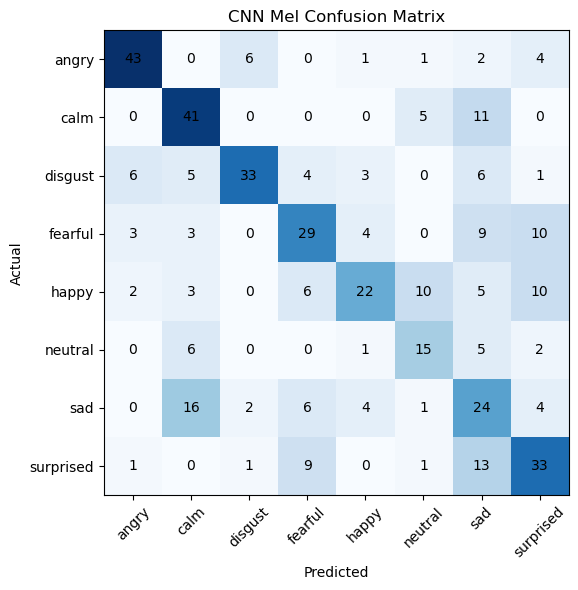


CNN Mel Classification Report
              precision    recall  f1-score   support

       angry       0.78      0.75      0.77        57
        calm       0.55      0.72      0.63        57
     disgust       0.79      0.57      0.66        58
     fearful       0.54      0.50      0.52        58
       happy       0.63      0.38      0.47        58
     neutral       0.45      0.52      0.48        29
         sad       0.32      0.42      0.36        57
   surprised       0.52      0.57      0.54        58

    accuracy                           0.56       432
   macro avg       0.57      0.55      0.55       432
weighted avg       0.58      0.56      0.56       432



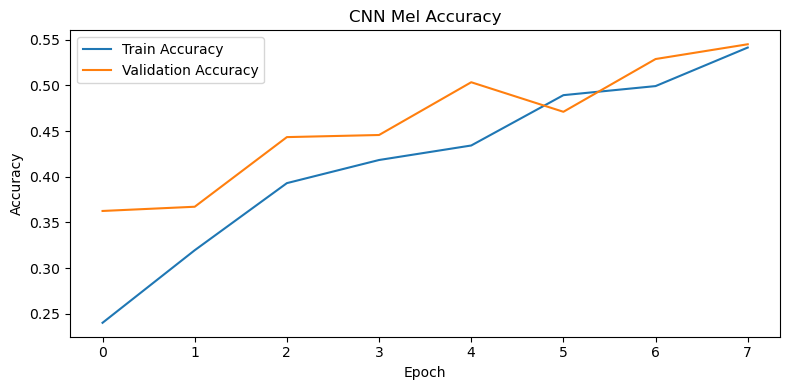

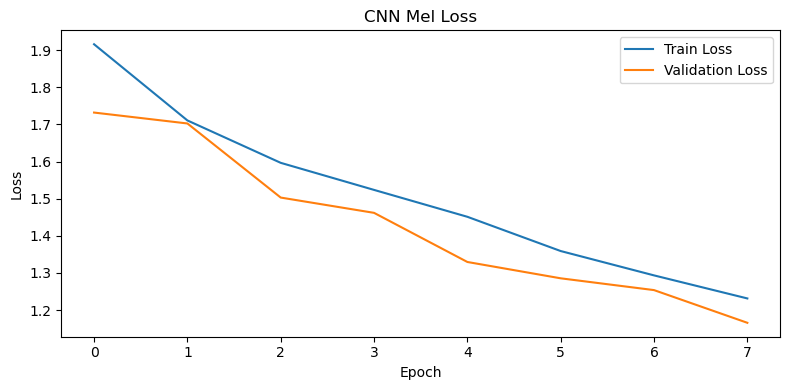

{'model': 'CNN Mel', 'accuracy': 0.5555555555555556, 'precision': 0.5802071879704982, 'recall': 0.5555555555555556, 'f1': 0.5586583354831459, 'roc_auc': 0.8980502093614341}


In [18]:
# =========================
# 15. TRAIN CNN ON MEL-SPECTROGRAMS
# =========================
if len(train_df):
    cnn_train_loader, cnn_val_loader, cnn_test_loader = make_loaders("mel")

    cnn_model = CNNMelNet(len(label_encoder.classes_)).to(DEVICE)
    cnn_history = train_model(cnn_model, cnn_train_loader, cnn_val_loader, "ravdess_cnn_mel.pt")

    cnn_model.load_state_dict(torch.load(CKPT_DIR / "ravdess_cnn_mel.pt", map_location=DEVICE))
    cnn_results = evaluate_model(cnn_model, cnn_test_loader, "CNN Mel")
    plot_history(cnn_history, "CNN Mel", "ravdess_cnn_mel")
    print(cnn_results)
else:
    print("Training data not available.")

Epoch 1/8: 100%|██████████| 126/126 [01:22<00:00,  1.52it/s]


Epoch 1: train_loss=2.0097, val_loss=1.8974, train_acc=0.1851, val_acc=0.2841


Epoch 2/8: 100%|██████████| 126/126 [01:29<00:00,  1.42it/s]


Epoch 2: train_loss=1.8567, val_loss=1.7505, train_acc=0.2849, val_acc=0.3303


Epoch 3/8: 100%|██████████| 126/126 [01:36<00:00,  1.30it/s]


...

Epoch 6: train_loss=1.3675, val_loss=1.2601, train_acc=0.4893, val_acc=0.5520


Epoch 7/8: 100%|██████████| 126/126 [01:38<00:00,  1.28it/s]


Epoch 7: train_loss=1.2694, val_loss=1.2040, train_acc=0.5275, val_acc=0.5473


Epoch 8/8: 100%|██████████| 126/126 [01:34<00:00,  1.33it/s]


Epoch 8: train_loss=1.1485, val_loss=1.1820, train_acc=0.5762, val_acc=0.5658


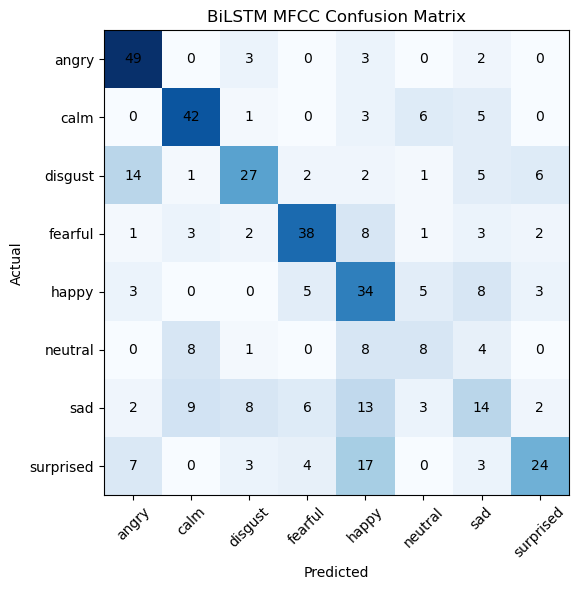


BiLSTM MFCC Classification Report
              precision    recall  f1-score   support

       angry       0.64      0.86      0.74        57
        calm       0.67      0.74      0.70        57
     disgust       0.60      0.47      0.52        58
     fearful       0.69      0.66      0.67        58
       happy       0.39      0.59      0.47        58
     neutral       0.33      0.28      0.30        29
         sad       0.32      0.25      0.28        57
   surprised       0.65      0.41      0.51        58

    accuracy                           0.55       432
   macro avg       0.54      0.53      0.52       432
weighted avg       0.55      0.55      0.54       432



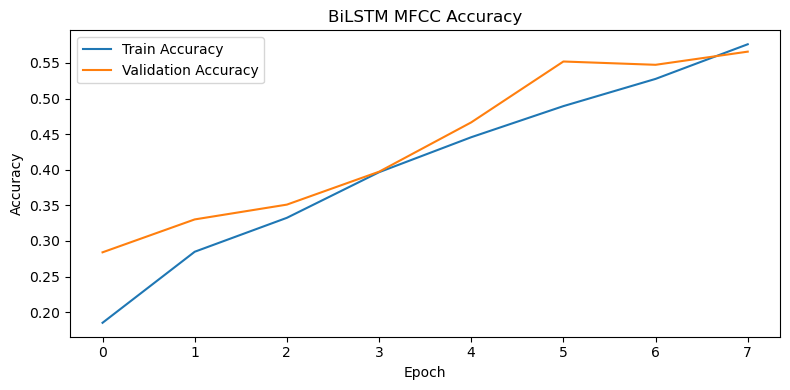

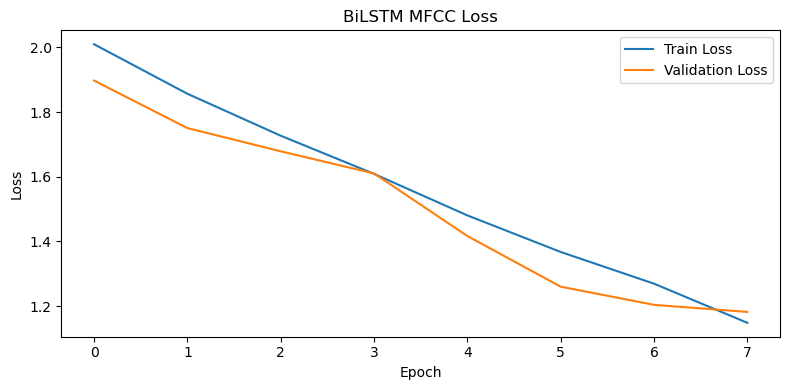

{'model': 'BiLSTM MFCC', 'accuracy': 0.5462962962962963, 'precision': 0.5496677548760882, 'recall': 0.5462962962962963, 'f1': 0.5374821192476782, 'roc_auc': 0.8830282834128189}


In [19]:
# =========================
# 16. TRAIN BILSTM ON MFCC SEQUENCES
# =========================
if len(train_df):
    lstm_train_loader, lstm_val_loader, lstm_test_loader = make_loaders("mfcc")

    lstm_model = BiLSTMMFCCNet(len(label_encoder.classes_)).to(DEVICE)
    lstm_history = train_model(lstm_model, lstm_train_loader, lstm_val_loader, "ravdess_bilstm_mfcc.pt")

    lstm_model.load_state_dict(torch.load(CKPT_DIR / "ravdess_bilstm_mfcc.pt", map_location=DEVICE))
    lstm_results = evaluate_model(lstm_model, lstm_test_loader, "BiLSTM MFCC")
    plot_history(lstm_history, "BiLSTM MFCC", "ravdess_bilstm_mfcc")
    print(lstm_results)
else:
    print("Training data not available.")

         model  accuracy  precision    recall        f1   roc_auc
0      CNN Mel  0.555556   0.580207  0.555556  0.558658  0.898050
1  BiLSTM MFCC  0.546296   0.549668  0.546296  0.537482  0.883028


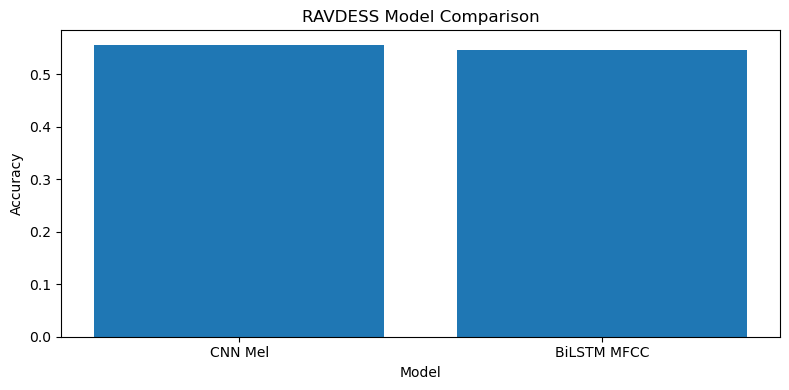

Saved outputs to: /home/ec2-user/SageMaker/ravdess_project/outputs
Saved figures to: /home/ec2-user/SageMaker/ravdess_project/figures


In [20]:
# =========================
# 17. MODEL COMPARISON FOR THESIS
# =========================
if len(train_df):
    results_df = pd.DataFrame([cnn_results, lstm_results])
    print(results_df)

    plt.figure(figsize=(8, 4))
    plt.bar(results_df["model"], results_df["accuracy"])
    plt.title("RAVDESS Model Comparison")
    plt.xlabel("Model")
    plt.ylabel("Accuracy")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "ravdess_model_comparison.png", dpi=220)
    plt.show()

    results_df.to_csv(OUT_DIR / "ravdess_model_results.csv", index=False)
    print("Saved outputs to:", OUT_DIR)
    print("Saved figures to:", FIG_DIR)
else:
    print("No results available.")